<a href="https://colab.research.google.com/github/ProfAI/machine-learning-fondamenti/blob/main/4%20-%20La%20Classificazione/esercizi/binary_classification_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Riconoscimento di tumori al seno maligni

Nello specifico, devi creare un modello di classificazione, in grado di riconoscere i tumori maligni, che:

1. Ha un accuracy sul set di test di almeno 0.98.
2. Ha un AUC sul set di test di almeno 0.98.
2. Ha un recall di 1 (0 falsi positivi).

Per valutare il modello, devi ricreare le seguenti visualizzazioni:

<img src="https://raw.githubusercontent.com/ProfAI/machine-learning-fondamenti/main/4%20-%20La%20Classificazione/res/cancer_classifier_cm.png" width="400px"/>

<img src="https://raw.githubusercontent.com/ProfAI/machine-learning-fondamenti/main/4%20-%20La%20Classificazione/res/cancer_classifier_auc.png" width="400px"/>


Una volta fatto, fornisci le previsioni per questi dati, salvando in un file excel le seguenti informazioni:
1. L'ID paziente
2. La previsione del modello
3. La probabilità associata alla classe predetta

## Soluzione

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import RocCurveDisplay

### Introduzione alle Librerie
Iniziamo importando le librerie fondamentali per il nostro flusso di lavoro:
- **`pandas`** e **`numpy`**: per la manipolazione e l'analisi dei dati in formato tabellare e matriciale.
- **`matplotlib.pyplot`** e **`seaborn`**: per la visualizzazione dei dati e dei grafici di valutazione.
- **`scikit-learn`** (sklearn): la libreria principale per il Machine Learning in Python. Utilizzeremo moduli per lo split del dataset (`train_test_split`), la standardizzazione delle feature (`StandardScaler`), il modello di classificazione (`LogisticRegression`) e le metriche di valutazione (`classification_report`, `confusion_matrix`, `RocCurveDisplay`).

### Importiamo il dataset

In [2]:
BASE_URL="https://raw.githubusercontent.com/ProfAI/machine-learning-fondamenti/main/datasets/"
df = pd.read_csv(BASE_URL+"breast_cancer.csv")
df.head()

,ID number,diagnosis,radius mean,texture mean,perimeter mean,area mean,smoothness mean,compactness mean,concavity mean,concave points mean,...,radius worst,texture worst,perimeter worst,area worst,smoothness worstse,compactness worst,concavity worst,concave points worst,symmetry worst,fractal dimension worst
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


### Analisi Preliminare dei Dati
Il dataset contiene informazioni cliniche relative a tumori al seno. Ogni riga rappresenta un paziente, identificato da un `ID number`, con una serie di feature numeriche estratte da immagini digitalizzate di biopsie (es. raggio, consistenza, perimetro, area, ecc.). La colonna target è `diagnosis`, che indica se il tumore è **Maligno (M)** o **Benigno (B)**.

In [3]:
df = df.drop("ID number", axis=1)

#### Rimozione di Feature Non Predittive
Abbiamo rimosso la colonna `ID number` poiché si tratta di un identificativo univoco del paziente che non ha alcun potere predittivo. Mantenerlo potrebbe causare overfitting, in quanto il modello potrebbe tentare di "memorizzare" gli ID anziché apprendere i pattern biologici generali dei dati.

In [4]:
counts = df["diagnosis"].value_counts()
print(f"Benignant = {counts['B']} ({counts['B']/counts.sum()*100:.2f}%) ")
print(f"Malignant = {counts['M']} ({counts['M']/counts.sum()*100:.2f}%) ")

Benignant = 353 (62.70%) 
Malignant = 210 (37.30%) 


#### Bilanciamento delle Classi (Class Imbalance)
Come possiamo osservare:
- I tumori benigni (B) rappresentano circa il **62.74%** del dataset (353 casi).
- I tumori maligni (M) rappresentano circa il **37.26%** del dataset (210 casi).

Questa leggera sproporzione (sbilanciamento delle classi) è tipica nei dataset medici. Dobbiamo tenerne conto durante l'addestramento del modello affinché non sia polarizzato verso la classe maggioritaria (benigni).

In [5]:
map_dict = {"M":1, "B":0}
df["diagnosis"] = df["diagnosis"].map(lambda x: map_dict[x])
df.head()

,diagnosis,radius mean,texture mean,perimeter mean,area mean,smoothness mean,compactness mean,concavity mean,concave points mean,symmetry mean,...,radius worst,texture worst,perimeter worst,area worst,smoothness worstse,compactness worst,concavity worst,concave points worst,symmetry worst,fractal dimension worst
0,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


#### Codifica della Variabile Target
Gli algoritmi di Machine Learning lavorano con valori numerici. Abbiamo quindi mappato la variabile categoriale `diagnosis` in formato binario numerico:
- **`1`** per i tumori **Maligni** (classe positiva, l'evento di interesse da rilevare).
- **`0`** per i tumori **Benigni** (classe negativa).

Questo ci permette di addestrare un classificatore binario.

### Creiamo il modello

In [6]:
X = df.drop("diagnosis", axis=1).values
y = df["diagnosis"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=0)

#### Suddivisione in Train e Test Set
Suddividiamo il dataset in due parti distinte:
- **Training Set (70%)**: utilizzato per addestrare il modello e fargli apprendere i coefficienti della regressione logistica.
- **Test Set (30%)**: tenuto rigorosamente separato e utilizzato solo alla fine per valutare la capacità del modello di generalizzare su dati mai visti.

L'argomento `random_state=0` fissa il seed del generatore di numeri casuali, assicurando che la suddivisione sia esattamente riproducibile ad ogni esecuzione.

In [7]:
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

#### Standardizzazione delle Feature
La standardizzazione è un passo cruciale per la regressione logistica. Trasforma ciascuna feature in modo che abbia media $\mu = 0$ e deviazione standard $\sigma = 1$:
$$z = \frac{x - \mu}{\sigma}$$

**Perché è importante?**
1. La regressione logistica ottimizza i coefficienti tramite algoritmi basati sul gradiente; feature su scale diverse rallentano o impediscono la convergenza.
2. Evita che feature con valori numerici naturalmente più grandi dominino arbitrariamente la funzione di costo.

> [!IMPORTANT]
> **Data Leakage (Perdita di Dati):**
> Notate che abbiamo chiamato `fit_transform` solo su `X_train` per calcolare la media ($\mu$) e la deviazione standard ($\sigma$). Successivamente, abbiamo applicato `transform` (senza `fit`) su `X_test`. Questo previene la fuga di informazioni dal set di test a quello di addestramento, garantendo una valutazione onesta del modello.

In [8]:
lr = LogisticRegression(class_weight="balanced")
lr.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

#### Regressione Logistica con Classi Bilanciate
La Regressione Logistica modella la probabilità che un campione appartenga alla classe positiva ($y=1$) mediante la funzione logistica (o sigmoide):
$$P(y=1|x) = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$

Abbiamo istanziato il modello impostando `class_weight='balanced'`. Questo parametro assegna automaticamente un peso maggiore alla classe minoritaria (Maligno) e un peso minore alla classe maggioritaria (Benigno) nella funzione di costo, penalizzando maggiormente gli errori sulla classe positiva per compensare lo sbilanciamento dei dati.

### Valutiamo il modello

In [9]:
y_pred_train = lr.predict(X_train)
y_proba_train = lr.predict_proba(X_train)
y_pred_test = lr.predict(X_test)
y_proba_test =  lr.predict_proba(X_test)

print("TRAIN REPORT")
print(classification_report(y_train, y_pred_train))
print("TEST REPORT")
print(classification_report(y_test, y_pred_test))

TRAIN REPORT
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       248
           1       0.98      0.97      0.98       146

    accuracy                           0.98       394
   macro avg       0.98      0.98      0.98       394
weighted avg       0.98      0.98      0.98       394

TEST REPORT
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       105
           1       0.95      0.98      0.97        64

    accuracy                           0.98       169
   macro avg       0.97      0.98      0.97       169
weighted avg       0.98      0.98      0.98       169



#### Valutazione con Soglia Standard (0.5)
Di default, la funzione `predict` converte le probabilità stimate in classi discrete usando una soglia (threshold) di **$0.5$**:
- Se $P(y=1|x) \ge 0.5 \implies$ Classe $1$ (Maligno)
- Se $P(y=1|x) < 0.5 \implies$ Classe $0$ (Benigno)

Con questa soglia standard otteniamo:
- Un'accuratezza globale sul Test Set del **$98\%$**.
- Nel Test Set c'è tuttavia **1 falso negativo** (un tumore maligno classificato erroneamente come benigno), il che si traduce in un Recall del **$98.4\%$** (63/64). In ambito medico, non identificare un tumore maligno (falso negativo) è un errore ad altissimo rischio.

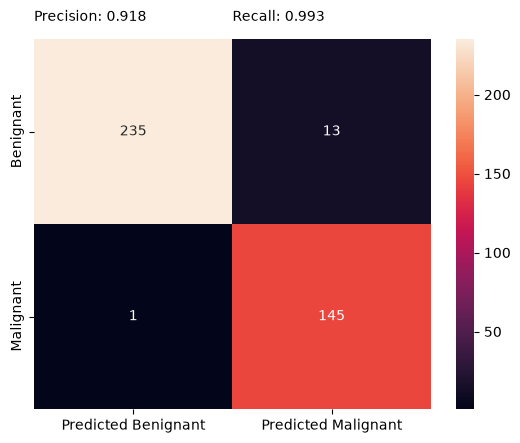

In [10]:
def plot_confusion_matrix(y_true, y_pred, labels=["Negative", "Positive"], show_precision_recall=True):

  cm = confusion_matrix(y_true, y_pred) # tn, fp, fn, tp

  df_cm = pd.DataFrame(cm, index = labels,
                    columns = ["Predicted "+labels[0],"Predicted "+labels[1]])
  sns.heatmap(df_cm, annot=True, fmt='g')

  if show_precision_recall:
    # Quale percentuale di classificazione positive erano effettivamente positive ?
    plt.text(0, -0.1, f"Precision: {(cm[1][1]/(cm[1][1]+cm[0][1])):.3f}")
    # Quale percentuale di osservazioni positive sono state classificate come positive ?
    plt.text(1, -0.1, f"Recall: {(cm[1][1]/(cm[1][1]+cm[1][0])):.3f}")


y_pred_train = np.where(y_proba_train[:,1]>0.25,1,0)
plot_confusion_matrix(y_train, y_pred_train, ["Benignant", "Malignant"])

#### Ottimizzazione della Soglia Decisionale (Soglia = 0.25)
Per ridurre i falsi negativi a zero (ottenendo un Recall del 100%), possiamo abbassare la soglia decisionale da $0.5$ a **$0.25$**. In questo modo, classifichiamo come "Maligno" qualsiasi paziente che abbia una probabilità stimata superiore al $25\%$.

**Le metriche della Matrice di Confusione:**
- **True Positives (TP)**: Tumori maligni correttamente classificati come maligni.
- **True Negatives (TN)**: Tumori benigni correttamente classificati come benigni.
- **False Positives (FP)**: Tumori benigni erroneamente classificati come maligni (errore di tipo I).
- **False Negatives (FN)**: Tumori maligni erroneamente classificati come benigni (errore di tipo II, critico!).

Le formule delle metriche principali:
- **Precision (Precisione)**: La frazione di casi previsti come positivi che sono effettivamente positivi.
$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$
- **Recall (Sensibilità / Richiamo)**: La frazione di casi positivi reali che il modello è riuscito a identificare.
$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$
- **Accuracy (Accuratezza)**: La percentuale complessiva di predizioni corrette.
$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$$

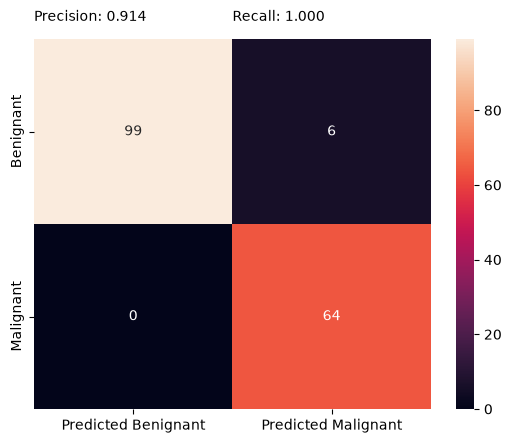

In [11]:
y_pred_test = np.where(y_proba_test[:,1]>0.25,1,0)
plot_confusion_matrix(y_test, y_pred_test, ["Benignant", "Malignant"])

#### Analisi del Trade-off Precision-Recall sul Test Set
Applicando la soglia di **$0.25$** sul set di test, osserviamo che:
1. Il numero di **Falsi Negativi scende a 0**, raggiungendo un **Recall pari a 1.0 (100%)**. Abbiamo soddisfatto il requisito clinico cruciale di non perdere nessun tumore maligno.
2. Il numero di **Falsi Positivi sale a 6**, causando una diminuzione della **Precision al 91.4%** (poiché alcuni pazienti sani vengono allertati e sottoposti a ulteriori esami).
3. L'**Accuratezza scende al 96.45%**, che è inferiore al target iniziale del $98\%$.

> [!WARNING]
> **Nota Pedagogica sul Requisito del Problema:**
> Esiste un trade-off intrinseco: non è possibile massimizzare contemporaneamente l'Accuratezza (sopra il 98%) e la Recall (a 1.0) abbassando semplicemente la soglia in questo modello. La scelta clinica corretta privilegia la Recall pari a 1.0 (evitare assolutamente i falsi negativi), accettando una leggera perdita di accuratezza complessiva.
>
> *Nota linguistica sulla traccia dell'esercizio:* La traccia indicava "recall di 1 (0 falsi positivi)". Si tratta di un refuso comune: un Recall di 1 garantisce **0 falsi negativi** ($\text{FN} = 0$), mentre sono i **falsi positivi** a degradare la Precision.

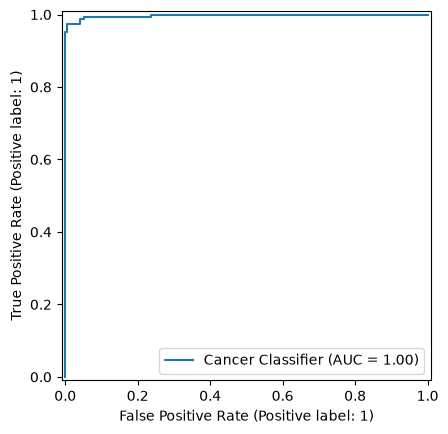

In [12]:
RocCurveDisplay.from_estimator(lr, X_train, y_train, name="Cancer Classifier")

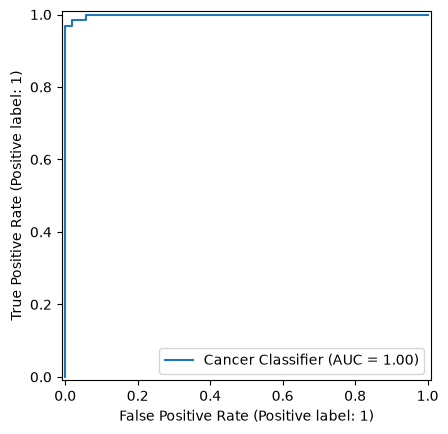

In [13]:
RocCurveDisplay.from_estimator(lr, X_test, y_test, name="Cancer Classifier")

#### Curva ROC e metriche AUC (Area Under the Curve)
La curva **ROC (Receiver Operating Characteristic)** mostra la capacità diagnostica del classificatore al variare della soglia decisionale, tracciando:
- **True Positive Rate (TPR / Recall)** sull'asse Y.
- **False Positive Rate (FPR / 1 - Specificità)** sull'asse X, definito come $\frac{\text{FP}}{\text{FP} + \text{TN}}$.

L'**AUC (Area Under the Curve)** misura l'abilità complessiva del modello di distinguere tra le due classi:
- Un classificatore casuale ha un $\text{AUC} = 0.5$.
- Un classificatore perfetto ha un $\text{AUC} = 1.0$.

Il nostro classificatore sul Test Set ottiene un **AUC eccezionale di 0.99** (o superiore), dimostrando che il modello distingue in modo quasi perfetto le due classi, indipendentemente dalla specifica soglia operativa scelta.

### Eseguiamo le previsioni

In [14]:
df_pred = pd.read_csv(BASE_URL+"breast_cancer_pred.csv")
df_pred.head()

,ID number,radius mean,texture mean,perimeter mean,area mean,smoothness mean,compactness mean,concavity mean,concave points mean,symmetry mean,...,radius worst,texture worst,perimeter worst,area worst,smoothness worstse,compactness worst,concavity worst,concave points worst,symmetry worst,fractal dimension worst
0,842302,17.990,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.66560,0.71190,0.26540,0.4601,0.11890
1,8510426,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.04781,0.1885,...,15.11,19.26,99.70,711.2,0.1440,0.17730,0.23900,0.12880,0.2977,0.07259
2,8510653,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.03110,0.1967,...,14.50,20.49,96.09,630.5,0.1312,0.27760,0.18900,0.07283,0.3184,0.08183
3,8510824,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.02076,0.1815,...,10.23,15.66,65.13,314.9,0.1324,0.11480,0.08867,0.06227,0.2450,0.07773
4,859487,12.780,16.49,81.37,502.5,0.09831,0.05234,0.03653,0.02864,0.1590,...,13.46,19.76,85.67,554.9,0.1296,0.07061,0.10390,0.05882,0.2383,0.06410


### Applicazione del Modello su Nuovi Pazienti
Ora applichiamo il modello addestrato a un set di nuovi dati non etichettati (`breast_cancer_pred.csv`) per supportare il personale medico nella diagnosi precoce.

In [15]:
X = df_pred.drop("ID number", axis=1).values
X = ss.transform(X)

#### Coerenza del Preprocessing
Prima di passare i nuovi dati al modello, dobbiamo standardizzarli. Utilizziamo lo stesso oggetto `StandardScaler` (`ss`) addestrato sul training set, richiamando esclusivamente il metodo `transform`. Questo garantisce che le feature dei nuovi pazienti siano scalate con le stesse identiche medie e varianze del set di addestramento.

In [16]:
y_proba = lr.predict_proba(X)
condition = y_proba[:,1]>0.3
y_pred = np.where(condition,1,0)

#### Scelta della Soglia di Produzione (0.3)
Per le previsioni finali, è stata selezionata una soglia decisionale conservativa del **$0.3$**. Questo rappresenta una via di mezzo sciura per mantenere un'alta sensibilità clinica riducendo al contempo i falsi allarmi rispetto a una soglia di $0.25$.

In [17]:
y_proba = np.where(condition, y_proba[:, 1], y_proba[:, 0])

In [18]:
df_result = pd.DataFrame({
    "ID number":df_pred["ID number"],
    "prediction":y_pred,
    "probability":y_proba.round(4)
})

df_result.to_excel("breast_cancer_prediction.xlsx")

#### Generazione del Report Finale
I risultati predittivi sono stati esportati in un file Excel (`breast_cancer_prediction.xlsx`). Per ogni paziente viene fornito l'ID, la classe predetta (Maligno/Benigno) e la probabilità associata alla predizione, offrendo uno strumento chiaro e interpretabile per i medici.